In [1]:
# --- Cell 1: Mount Drive ---
from google.colab import drive
drive.mount('/content/drive')

# --- Cell 2: Set Cache (Fast) ---
import os
DRIVE_CACHE_DIR = '/content/drive/MyDrive/2025.10.L4GPU/pip-cache'
DRIVE_WHEEL_DIR = '/content/drive/MyDrive/2025.10.L4GPU/pip-wheelhouse'
os.environ['PIP_CACHE_DIR'] = DRIVE_CACHE_DIR

# --- Cell 3: Install from Cache (Very Fast) ---

# 1. Install PyTorch
!pip install torch==2.3.1 torchvision==0.18.1 --index-url https://download.pytorch.org/whl/cu121

# 2. Install mmcv FROM YOUR PRE-BUILT WHEEL
# --no-index tells pip "Don't look online"
# --find-links tells it "Only look in my wheelhouse folder"
!pip install mmcv==2.1.0 --no-index --find-links={DRIVE_WHEEL_DIR}

# 3. Install the rest (pip will find these in your cache)
!pip install "mmdet==3.3.0"
!pip install "mmsegmentation==1.2.2"
!pip install "ftfy"

Mounted at /content/drive
Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download.pytorch.org/whl/cu121/torch-2.3.1%2Bcu121-cp312-cp312-linux_x86_64.whl (780.9 MB)
  Using cached https://download.pytorch.org/whl/cu121/torchvision-0.18.1%2Bcu121-cp312-cp312-linux_x86_64.whl (7.0 MB)
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached https://download.pytorch.org/whl/cu121

In [2]:
import torch
import mmcv
import mmdet
import mmseg

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MMCV version: {mmcv.__version__}")
print(f"MMSegmentation version: {mmseg.__version__}")

PyTorch version: 2.3.1+cu121
CUDA available: True
MMCV version: 2.1.0
MMSegmentation version: 1.2.2


In [3]:
# --- CHANGE THIS ---
# Set your project directory
PROJECT_DIR = '/content/drive/MyDrive/Projects/thesis_project'
# -----------------

# Change to the project directory
os.chdir(PROJECT_DIR)

# Verify
print(f"Current working directory: {os.getcwd()}")

Current working directory: /content/drive/MyDrive/Projects/thesis_project


In [4]:
# 1. SET THE CONFIG FILE FOR THE MODEL YOU WANT TO TEST
CONFIG_FILE = 'configs/segmenter_vit-l_mask_b2-20k_vaihingen-512x512.py'

# 2. SET THE CHECKPOINT FILE (THE BEST SAVED MODEL)
# Find this in your 'work_dirs/' folder for that model.
# It's the one named "best_mIoU_..."
CHECKPOINT_FILE = 'work_dirs/segmenter/best_mIoU_iter_30000.pth' # <-- EXAMPLE: Change this!

# 3. SET A NEW WORK_DIR FOR THIS *EVALUATION* RUN
# This is where your new test results and visuals will be saved.
EVAL_WORK_DIR = 'work_dirs/EVAL_segmenter'

# 4. SET THE ORIGINAL *TRAINING* LOG FILE
# This is used to plot the learning curves.
# It's the .log.json file from the *original* training run.
TRAIN_LOG_FILE = '/content/drive/MyDrive/Projects/thesis_project/work_dirs/segmenter/20251128_170948/vis_data/20251128_170948.json' # <-- EXAMPLE: Change this!

In [5]:
print(f"Generating visualizations...")

!python mmsegmentation-main/tools/test.py \
    {CONFIG_FILE} \
    {CHECKPOINT_FILE} \
    --show-dir {EVAL_WORK_DIR}/visualizations

print(f"\n✅ Visualizations saved to: {EVAL_WORK_DIR}/visualizations")
print("Go check the folder in the Google Drive file browser!")

Generating visualizations...
11/30 04:12:35 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 69250551
    GPU 0: NVIDIA L4
    CUDA_HOME: /usr/local/cuda
    NVCC: Cuda compilation tools, release 12.5, V12.5.82
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04.2) 11.4.0
    PyTorch: 2.3.1+cu121
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.3.6 (Git Hash 86e6af5974177e513fd3fee58425e1063e7f1361)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX512
  - CUDA Runtime 12.1
  - NVCC architecture flags: -

Plotting learning curves from: /content/drive/MyDrive/Projects/thesis_project/work_dirs/segmenter_2/20251117_192106/vis_data/20251117_192106.json
plot curve of /content/drive/MyDrive/Projects/thesis_project/work_dirs/segmenter_2/20251117_192106/vis_data/20251117_192106.json, metric is mIoU
plot curve of /content/drive/MyDrive/Projects/thesis_project/work_dirs/segmenter_2/20251117_192106/vis_data/20251117_192106.json, metric is loss
save curve to: work_dirs/EVAL_segmenter_2/learning_curve.png

✅ Learning curve plot saved to: work_dirs/EVAL_segmenter_2/learning_curve.png


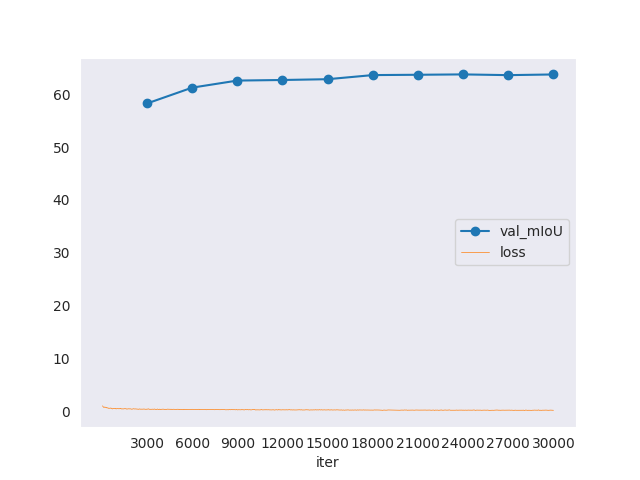

In [ ]:
from IPython.display import Image, display
import os

print(f"Plotting learning curves from: {TRAIN_LOG_FILE}")

# Define the output file name
curve_png_file = f"{EVAL_WORK_DIR}/learning_curve.png"

# Run the analysis tool
# --- CORRECTED KEYS ---
!python mmsegmentation-main/tools/analysis_tools/analyze_logs.py \
    {TRAIN_LOG_FILE} \
    --keys mIoU loss \
    --legend val_mIoU loss \
    --out {curve_png_file}

# Display the generated image
if os.path.exists(curve_png_file):
    print(f"\n✅ Learning curve plot saved to: {curve_png_file}")
    display(Image(filename=curve_png_file))
else:
    print(f"\n❌ Error: Log file not found or plot could not be generated.")

In [ ]:
setrTRAIN_LOG_FILE = '/content/drive/MyDrive/Projects/thesis_project/work_dirs/setr_3/20251117_192938/vis_data/20251117_192938.json' # <-- EXAMPLE: Change this!

TRAIN_LOG_FILE = '/content/drive/MyDrive/Projects/thesis_project/work_dirs/segmenter_2/20251117_192106/vis_data/20251117_192106.json' # <-- EXAMPLE: Change this!






